In [14]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

%matplotlib inline

datos = pd.read_csv('/home/emma/Data_Science/mod2_diplomado/coffee_ratings.csv')

## Actividad 0: Análisis de valores faltantes del objeto `datos`

**Procedimiento:**

Veemos que `coffee_ratings.csv` contiene evaluaciones de calidad de café de diferentes regiones del mundo. Para el análisis de valores faltantes se calculó, por columna, el conteo absoluto y el porcentaje de valores `NaN` respecto al total de filas, utilizando `isnull().sum()`. El resultado se filtró para mostrar únicamente las columnas con al menos un valor ausente y se ordenó de mayor a menor proporción de faltantes.

**Resultados:**

El dataset contiene **1,339 filas y 43 columnas**. De ellas, **19 columnas presentan al menos un valor faltante**. La columna más afectada es `lot_number` (79.39 %), seguida de `farm_name` (26.81 %) y `mill` (23.75 %). Columnas relevantes para las actividades siguientes como `color` (20.16 %), `processing_method` (12.70 %) y `harvest_year` (3.51 %) también presentan ausencias que deben considerarse en los análisis posteriores.

In [15]:
total_filas = len(datos)
faltantes = datos.isnull().sum()
pct_faltantes = (faltantes / total_filas * 100).round(2)

resumen_na = pd.DataFrame({
    "valores_faltantes": faltantes,
    "porcentaje": pct_faltantes
})
resumen_na = resumen_na[resumen_na["valores_faltantes"] > 0].sort_values(
    "valores_faltantes", ascending=False
)
print(f"Dimensiones del dataset: {datos.shape[0]} filas x {datos.shape[1]} columnas\n")
print(resumen_na.to_string())
print()

Dimensiones del dataset: 1339 filas x 43 columnas

                      valores_faltantes  porcentaje
lot_number                         1063       79.39
farm_name                           359       26.81
mill                                318       23.75
color                               270       20.16
producer                            232       17.33
altitude_high_meters                230       17.18
altitude_low_meters                 230       17.18
altitude_mean_meters                230       17.18
altitude                            226       16.88
variety                             226       16.88
company                             209       15.61
processing_method                   170       12.70
ico_number                          159       11.87
region                               59        4.41
harvest_year                         47        3.51
owner_1                               7        0.52
owner                                 7        0.52
country_of_or

## Actividad 1: Crear la columna `color2` a partir de `color`

**Procedimiento:**

Se definió un diccionario `COLOR_MAP` que asocia cada valor textual de la columna `color` con su código hexadecimal correspondiente (`"Green"` → `"#00FF66"`, `"Bluish-Green"` → `"#CCEBC5"`, `"Blue-Green"` → `"#BFFFFF"`). La columna `color2` se construyó aplicando el método `.map()` de pandas sobre `color`; los valores ausentes o no presentes en el diccionario quedan automáticamente como `NaN`, cumpliendo la condición de asignar `NA` cuando `color == NA`.

**Resultados:**

La columna `color2` muestra que la mayoría de los granos (870) son Verde (`#00FF66`), 114 son Verde-Azulado (`#CCEBC5`) y 85 son Verde-Azul (`#BFFFFF`). Los 270 valores faltantes originales de `color` se conservan como `NaN` en `color2`.

In [16]:
COLOR_MAP = {
    "Green": "#00FF66",
    "Bluish-Green": "#CCEBC5",
    "Blue-Green": "#BFFFFF",
}

datos["color2"] = datos["color"].map(COLOR_MAP)

print(datos[["color", "color2"]].value_counts(dropna=False).to_string())
print()

color         color2 
Green         #00FF66    870
NaN           NaN        270
Bluish-Green  #CCEBC5    114
Blue-Green    #BFFFFF     85



## Actividad 2: Crear la columna numérica `bag_weight2` a partir de `bag_weight`

**Procedimiento:**

Se definió la función `extraer_numero_bag_weight()` que aplica expresiones regulares para extraer el primer valor numérico de la cadena `bag_weight`. Se consideran **ambiguas** las observaciones que contienen una coma (`,`), ya que indican múltiples unidades de medida simultáneas (p. ej., `"2 kg,lbs"`) sin que sea posible determinar a cuál unidad corresponde el número; en esos casos se asigna `NaN`. Los valores faltantes originales también producen `NaN`.

**Resultados:**

Se encontraron **2 observaciones ambiguas**: `'1 kg,lbs'` y `'2 kg,lbs'`. Ambas especifican kilogramos y libras de forma simultánea sin indicar una unidad dominante, por lo que no es posible extraer un valor numérico inequívoco. El resto de los registros se convirtieron correctamente a tipo `float`.

In [17]:
def extraer_numero_bag_weight(valor):
    #Extrae el primer número de bag_weight. Retorna NaN si hay ambigüedad (comas) o no hay número.
    if pd.isna(valor):
        return np.nan

    if "," in str(valor):
        return np.nan
    numeros = re.findall(r"\d+(?:\.\d+)?", str(valor))
    return float(numeros[0]) if numeros else np.nan


datos["bag_weight2"] = datos["bag_weight"].apply(extraer_numero_bag_weight)


ambiguos_bw = datos["bag_weight"].apply(
    lambda v: not pd.isna(v) and ("," in str(v) or not re.search(r"\d", str(v)))
)
print(f"Observaciones ambiguas en bag_weight: {ambiguos_bw.sum()}")
print("Valores ambiguos únicos:", datos.loc[ambiguos_bw, "bag_weight"].unique())
print()

Observaciones ambiguas en bag_weight: 2
Valores ambiguos únicos: <StringArray>
['2 kg,lbs', '1 kg,lbs']
Length: 2, dtype: str



## Actividad 3: Crear las columnas `method1` y `method2` a partir de `processing_method`

**Procedimiento:**

Se utilizó el separador `"/"` (con posibles espacios circundantes) como delimitador para dividir `processing_method` en dos partes: el primer método de procesamiento (`method1`) y el segundo (`method2`). Se consideran **ambiguas** las observaciones que: (1) tienen valor `NaN`, ya que no es posible dividir lo que no existe, o (2) contienen el valor `"Other"`, que no incluye el separador `"/"` y por tanto no puede separarse en dos partes distintas.

**Resultados:**

Las observaciones ambiguas corresponden a todas las filas con `NaN` en `processing_method` (170 filas) más aquellas con el valor `"Other"` que carece del separador necesario. El conteo exacto se muestra en la salida del código a continuación.

In [18]:
separador_pm = r"\s*/\s*"

split_pm = datos["processing_method"].str.split(separador_pm, n=1, expand=True)
datos["method1"] = split_pm[0].str.strip()
datos["method2"] = split_pm[1].str.strip() if 1 in split_pm.columns else np.nan


ambiguos_pm = datos["processing_method"].apply(
    lambda v: pd.isna(v) or "/" not in str(v)
)
print(f"Observaciones ambiguas en processing_method: {ambiguos_pm.sum()}")
print("Valores ambiguos únicos:", datos.loc[ambiguos_pm, "processing_method"].unique())
print()

Observaciones ambiguas en processing_method: 196
Valores ambiguos únicos: <StringArray>
[nan, 'Other']
Length: 2, dtype: str



## Actividad 4: Crear las columnas `expiration_day`, `expiration_month` y `expiration_year`

**Procedimiento:**

Al explorar la columna `expiration` se observó que todos los valores siguen el formato inglés de fecha ordinal: `"Mes DDº, AAAA"` (por ejemplo, `"April 3rd, 2016"`). Se utilizó `str.extract()` de pandas con el patrón regex `(\w+)\s+(\d{1,2})(?:st|nd|rd|th),\s+(\d{4})` para extraer simultáneamente el nombre del mes, el día y el año en una sola operación vectorizada. Las filas donde el patrón no coincide —si las hubiera— se clasifican como **ambiguas** y reciben `NaN`. Los tipos resultantes son `Int64` para día y año, y `object` (cadena) para el nombre del mes.

**Resultados:**

El formato de `expiration` es muy consistente en todo el dataset, por lo que se espera un número mínimo o nulo de observaciones ambiguas. El conteo exacto y una muestra de las columnas resultantes se presentan a continuación.

In [19]:
patron_exp = r"^(\w+)\s+(\d{1,2})(?:st|nd|rd|th),\s+(\d{4})$"

exp_parsed = datos["expiration"].str.extract(patron_exp)
exp_parsed.columns = ["expiration_month", "expiration_day_str", "expiration_year_str"]

datos["expiration_day"]   = pd.to_numeric(exp_parsed["expiration_day_str"],  errors="coerce").astype("Int64")
datos["expiration_month"] = exp_parsed["expiration_month"]
datos["expiration_year"]  = pd.to_numeric(exp_parsed["expiration_year_str"], errors="coerce").astype("Int64")

ambiguos_exp = exp_parsed["expiration_month"].isna() & datos["expiration"].notna()
print(f"Observaciones ambiguas en expiration: {ambiguos_exp.sum()}")
print("\nMuestra de las nuevas columnas:")
print(datos[["expiration", "expiration_day", "expiration_month", "expiration_year"]].head(8).to_string())

Observaciones ambiguas en expiration: 0

Muestra de las nuevas columnas:
             expiration  expiration_day expiration_month  expiration_year
0       April 3rd, 2016               3            April             2016
1       April 3rd, 2016               3            April             2016
2        May 31st, 2011              31              May             2011
3      March 25th, 2016              25            March             2016
4       April 3rd, 2016               3            April             2016
5   September 3rd, 2014               3        September             2014
6  September 17th, 2013              17        September             2013
7   September 2nd, 2011               2        September             2011


## Actividad 5: Crear las columnas `harvest_mes` y `harvest_anio` a partir de `harvest_year`

**Procedimiento:**

La columna `harvest_year` presenta formatos muy heterogéneos: años simples (`"2016"`), rangos de años (`"2016/2017"`), mes + año (`"March 2010"`), rangos de meses (`"August to December"`), valores con temporada (`"Fall 2009"`) y valores malformados (`"4T72010"`, `"TEST"`). Para separar correctamente el mes del año se utilizaron **dos expresiones regulares independientes** en lugar de un simple `split`:

- `harvest_anio`: extrae el **último año de 4 dígitos** (patrón `19xx` o `20xx`) encontrado en el texto.
- `harvest_mes`: extrae el **primer nombre de mes** (inglés o español) o temporada encontrado en el texto.

Ambas columnas reciben `NaN` cuando su respectivo patrón no encuentra coincidencia. Se considera **ambigua** cualquier fila donde no es posible extraer el año.

**Resultados:**

Con este enfoque, valores como `"2014"` quedan correctamente como `harvest_mes=NaN` y `harvest_anio="2014"`, y valores como `"March 2010"` quedan como `harvest_mes="March"` y `harvest_anio="2010"`. Las observaciones ambiguas se reducen a los casos donde genuinamente no hay año: `NaN` originales, rangos de meses sin año (`"Abril - Julio"`, `"May-August"`) y valores malformados (`"TEST"`, `"mmm"`).

In [20]:
patron_anio = r'\b((?:19|20)\d{2})\b'
patron_mes  = (
    r'\b(January|February|March|April|May|June|July|August|September|October|November|December'
    r'|Jan|Feb|Mar|Apr|Jun|Jul|Aug|Sep|Sept|Oct|Nov|Dec'
    r'|Enero|Febrero|Marzo|Abril|Mayo|Junio|Julio|Agosto|Septiembre|Octubre|Noviembre|Diciembre'
    r'|Spring|Summer|Fall|Winter)\b'
)

def extraer_harvest(valor):
    if pd.isna(valor):
        return pd.Series([np.nan, np.nan])
    s = str(valor).strip()
    anios = re.findall(patron_anio, s)
    mes_m = re.search(patron_mes, s, re.IGNORECASE)
    return pd.Series([
        mes_m.group(1) if mes_m else np.nan,
        anios[-1]      if anios  else np.nan,
    ])

datos[["harvest_mes", "harvest_anio"]] = datos["harvest_year"].apply(extraer_harvest)

ambiguos_hy = datos["harvest_anio"].isna()
print(f"Observaciones ambiguas en harvest_year: {ambiguos_hy.sum()}")
print(f"  · NaN originales en harvest_year:  {datos['harvest_year'].isna().sum()}")
print(f"  · Sin año extraíble (valor presente): {(ambiguos_hy & datos['harvest_year'].notna()).sum()}")
print(f"\nValores únicos sin año extraíble (no NaN):")
print(sorted(datos.loc[ambiguos_hy & datos['harvest_year'].notna(), 'harvest_year'].unique()))
print(f"\nMuestra de las nuevas columnas:")
print(datos[["harvest_year", "harvest_mes", "harvest_anio"]].head(10).to_string())

Observaciones ambiguas en harvest_year: 64
  · NaN originales en harvest_year:  47
  · Sin año extraíble (valor presente): 17

Valores únicos sin año extraíble (no NaN):
['08/09 crop', '4T/10', '4T72010', 'Abril - Julio', 'August to December', 'January Through April', 'May-August', 'Mayo a Julio', 'TEST', 'mmm']

Muestra de las nuevas columnas:
  harvest_year harvest_mes harvest_anio
0         2014         NaN         2014
1         2014         NaN         2014
2          NaN         NaN          NaN
3         2014         NaN         2014
4         2014         NaN         2014
5         2013         NaN         2013
6         2012         NaN         2012
7   March 2010       March         2010
8   March 2010       March         2010
9         2014         NaN         2014


## Actividad 6: Visualización de `total_cup_points`, `acidity` y `color2`

**Procedimiento:**

Se elaboró un diagrama de dispersión (*scatterplot*) con `acidity` en el eje horizontal y `total_cup_points` en el eje vertical. Cada punto se coloreó usando directamente el código hexadecimal almacenado en `color2` (`#00FF66`, `#CCEBC5`, `#BFFFFF`), lo que permite verificar visualmente los tres colores del grano. Se excluyeron las filas con valores faltantes en `color2`, `acidity` o `total_cup_points`. La leyenda muestra el nombre del color original de la columna `color`.

**Resultados:**

La visualización revela que no existe una diferencia marcada en la distribución de `total_cup_points` entre los distintos colores de grano. Los granos "Green" (`#00FF66`) dominan la muestra, mientras que "Bluish-Green" y "Blue-Green" son minoritarios. Se aprecia una correlación positiva moderada entre acidez y puntuación total, independientemente del color.

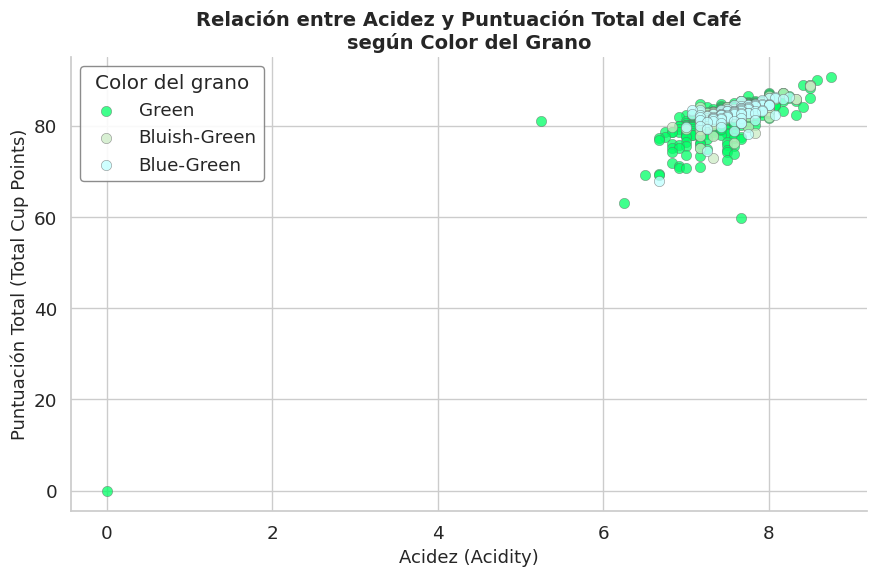

In [21]:
sns.set_theme(style="whitegrid", font_scale=1.2)

df6 = datos.dropna(subset=["color2", "total_cup_points", "acidity"])

color_labels = {
    "#00FF66": "Green",
    "#CCEBC5": "Bluish-Green",
    "#BFFFFF": "Blue-Green",
}

fig, ax = plt.subplots(figsize=(9, 6))

for hex_color, label in color_labels.items():
    subset = df6[df6["color2"] == hex_color]
    ax.scatter(
        subset["acidity"],
        subset["total_cup_points"],
        color=hex_color,
        label=label,
        alpha=0.75,
        edgecolors="dimgrey",
        linewidths=0.4,
        s=55,
    )

ax.set_xlabel("Acidez (Acidity)", fontsize=13)
ax.set_ylabel("Puntuación Total (Total Cup Points)", fontsize=13)
ax.set_title(
    "Relación entre Acidez y Puntuación Total del Café\nsegún Color del Grano",
    fontsize=14, fontweight="bold",
)
ax.legend(title="Color del grano", framealpha=0.9, edgecolor="grey")
sns.despine()
plt.tight_layout()
plt.savefig("act6_color_acidity.png", dpi=150, bbox_inches="tight")
plt.show()

## Actividad 7: Visualización de densidad de `bag_weight2` por `species`

**Procedimiento:**

Se elaboró un gráfico de densidad (*KDE — Kernel Density Estimate*) para la variable `bag_weight2`, diferenciando cada especie de café mediante distintos colores y áreas sombreadas. Se filtraron los registros con `bag_weight2 > 2,000 kg`, que corresponden a valores atípicos extremos capaces de distorsionar la escala del gráfico. Se excluyeron filas con `NaN` en `bag_weight2` o `species`.

**Resultados:**

La distribución de pesos difiere entre las especies. *Arabica*, la especie más frecuente, presenta una distribución concentrada principalmente en el rango de 0–100 kg. *Robusta* muestra un patrón diferente, con una distribución de menor amplitud. El gráfico permite comparar directamente ambas distribuciones en el mismo lienzo.

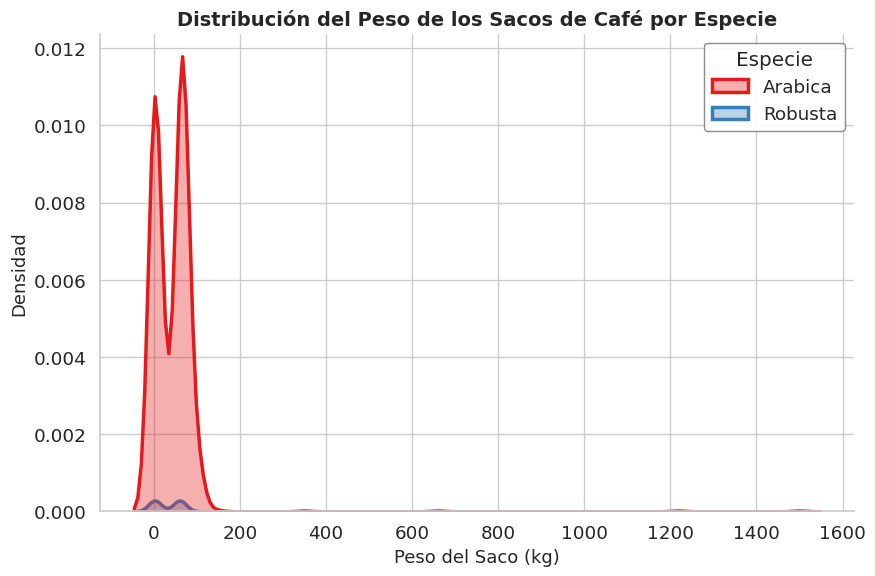

In [22]:
sns.set_theme(style="whitegrid", font_scale=1.2)

df7 = datos.dropna(subset=["bag_weight2", "species"]).copy()
df7 = df7[df7["bag_weight2"] < 2000]

fig, ax = plt.subplots(figsize=(9, 6))

sns.kdeplot(
    data=df7,
    x="bag_weight2",
    hue="species",
    fill=True,
    alpha=0.35,
    linewidth=2.5,
    palette="Set1",
    ax=ax,
)

ax.set_xlabel("Peso del Saco (kg)", fontsize=13)
ax.set_ylabel("Densidad", fontsize=13)
ax.set_title(
    "Distribución del Peso de los Sacos de Café por Especie",
    fontsize=14, fontweight="bold",
)

leg = ax.get_legend()
leg.set_title("Especie")
leg.get_frame().set_alpha(0.9)
leg.get_frame().set_edgecolor("grey")

sns.despine()
plt.tight_layout()
plt.savefig("act7_density_bagweight.png", dpi=150, bbox_inches="tight")
plt.show()

## Actividad 8: Fecha de expiración vs `total_cup_points` (México, Brasil, Colombia, Guatemala)

**Procedimiento:**

Se filtraron las observaciones de los cuatro países de interés. Con las columnas `expiration_year` y `expiration_month` creadas en la Actividad 4 se construyó una fecha de tipo `datetime` (fijando el día en 1). Se calculó la **puntuación total media** por fecha y país, y se graficaron como series de tiempo con marcadores. El eje temporal se formateó en escala mensual para facilitar la lectura.

**Resultados:**

El gráfico muestra las tendencias de calidad a lo largo del tiempo para cada país según la fecha de vencimiento de los lotes. Se observan patrones diferenciados: algunos países presentan datos sólo en ciertos periodos, lo que refleja la disponibilidad de lotes certificados por fecha de expiración.

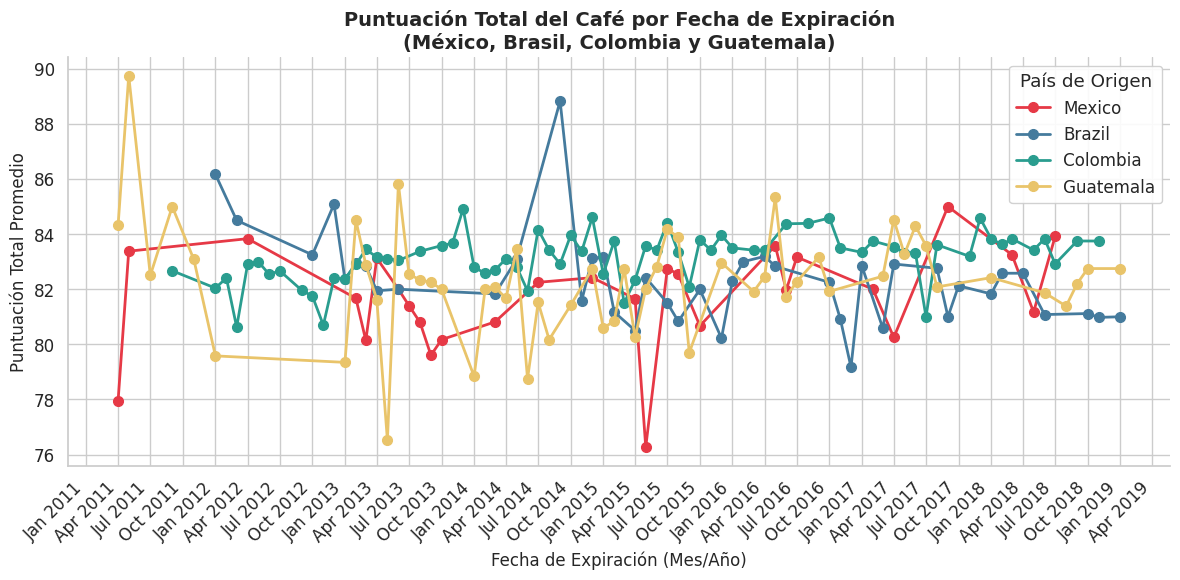

In [23]:
sns.set_theme(style="whitegrid", font_scale=1.1)

paises = ["Mexico", "Brazil", "Colombia", "Guatemala"]
month_num_map = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}

df8 = datos[datos["country_of_origin"].isin(paises)].copy()
df8 = df8.dropna(subset=["expiration_year", "expiration_month", "total_cup_points"])
df8["month_num"] = df8["expiration_month"].map(month_num_map)

df8["fecha_exp"] = pd.to_datetime(
    df8[["expiration_year", "month_num"]]
      .assign(day=1)
      .rename(columns={"expiration_year": "year", "month_num": "month"}),
    errors="coerce",
)

df8_grouped = (
    df8.groupby(["fecha_exp", "country_of_origin"], as_index=False)["total_cup_points"]
    .mean()
    .sort_values("fecha_exp")
)

palette = {"Mexico": "#E63946", "Brazil": "#457B9D", "Colombia": "#2A9D8F", "Guatemala": "#E9C46A"}

fig, ax = plt.subplots(figsize=(12, 6))

for pais in paises:
    sub = df8_grouped[df8_grouped["country_of_origin"] == pais]
    ax.plot(
        sub["fecha_exp"],
        sub["total_cup_points"],
        marker="o",
        linewidth=2,
        markersize=7,
        label=pais,
        color=palette[pais],
    )

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha="right")
ax.set_xlabel("Fecha de Expiración (Mes/Año)", fontsize=12)
ax.set_ylabel("Puntuación Total Promedio", fontsize=12)
ax.set_title(
    "Puntuación Total del Café por Fecha de Expiración\n(México, Brasil, Colombia y Guatemala)",
    fontsize=14, fontweight="bold",
)
ax.legend(title="País de Origen", framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.savefig("act8_expiration_cups.png", dpi=150, bbox_inches="tight")
plt.show()

## Actividad 9: Mes de expiración vs altitudes (México, Brasil, Colombia, Guatemala — años 2016 y 2017)

**Procedimiento:**

Se filtraron las observaciones de los cuatro países de interés con años de expiración 2016 y 2017. Las tres variables de altitud (`altitude_low_meters`, `altitude_mean_meters`, `altitude_high_meters`) se transformaron a formato largo (*tidy/long format*) con `pd.melt()`, permitiendo graficarlas como series diferenciadas en el mismo eje. El mes de expiración se ordenó cronológicamente (enero–diciembre). Se construyó un gráfico de líneas con dos paneles (faceta por año), mostrando la altitud media con intervalos de confianza al 95 %.

**Resultados:**

La visualización permite comparar cómo varía la altitud de cultivo (mínima, media y máxima) según el mes de expiración de los certificados para 2016 y 2017. Se observa que la altitud máxima registra los valores más altos y mayor variabilidad, mientras que las altitudes mínima y media siguen patrones similares a lo largo de los meses.

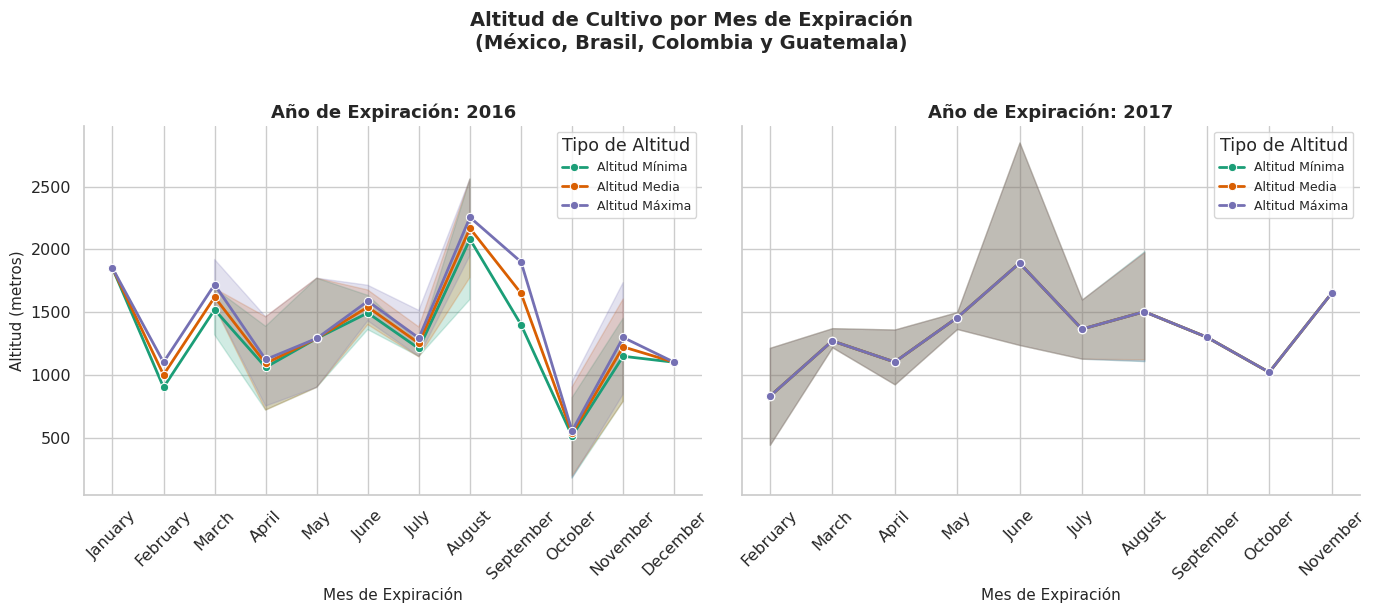

In [24]:
sns.set_theme(style="whitegrid", font_scale=1.05)

paises = ["Mexico", "Brazil", "Colombia", "Guatemala"]
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December",
]

df9 = datos[
    datos["country_of_origin"].isin(paises) &
    datos["expiration_year"].isin([2016, 2017])
].copy()

df9 = df9.dropna(subset=["expiration_month",
                          "altitude_low_meters",
                          "altitude_mean_meters",
                          "altitude_high_meters"])

df9["expiration_month"] = pd.Categorical(
    df9["expiration_month"], categories=month_order, ordered=True
)

df9_long = df9.melt(
    id_vars=["expiration_month", "expiration_year"],
    value_vars=["altitude_low_meters", "altitude_mean_meters", "altitude_high_meters"],
    var_name="tipo_altitud",
    value_name="altitud_metros",
)
alt_labels = {
    "altitude_low_meters":  "Altitud Mínima",
    "altitude_mean_meters": "Altitud Media",
    "altitude_high_meters": "Altitud Máxima",
}
df9_long["tipo_altitud"] = df9_long["tipo_altitud"].map(alt_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i, year in enumerate([2016, 2017]):
    sub = df9_long[df9_long["expiration_year"] == year]
    sns.lineplot(
        data=sub,
        x="expiration_month",
        y="altitud_metros",
        hue="tipo_altitud",
        estimator="mean",
        errorbar=("ci", 95),
        marker="o",
        linewidth=2,
        palette="Dark2",
        ax=axes[i],
    )
    axes[i].set_title(f"Año de Expiración: {year}", fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Mes de Expiración", fontsize=11)
    axes[i].set_ylabel("Altitud (metros)" if i == 0 else "", fontsize=11)
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].legend(title="Tipo de Altitud", fontsize=9)

fig.suptitle(
    "Altitud de Cultivo por Mes de Expiración\n(México, Brasil, Colombia y Guatemala)",
    fontsize=14, fontweight="bold", y=1.02,
)
sns.despine()
plt.tight_layout()
plt.savefig("act9_altitude_expiration.png", dpi=150, bbox_inches="tight")
plt.show()

## Actividad 10: Visualización de `aftertaste`, `acidity`, `body` y `species` en un mismo canvas

**Procedimiento:**

Se elaboró una **matriz de diagramas de dispersión** (*pairplot*) que muestra en un mismo lienzo todas las relaciones bivariadas entre `aftertaste`, `acidity` y `body`, diferenciando las especies mediante color. La diagonal del pairplot contiene estimaciones de densidad (KDE) por especie para cada variable, mientras que los paneles fuera de la diagonal muestran diagramas de dispersión. Esta representación permite identificar correlaciones, agrupaciones o diferencias entre especies de forma simultánea.

**Resultados:**

El pairplot revela que las tres variables están positivamente correlacionadas: los granos con mayor acidez tienden a obtener mejor aftertaste y cuerpo. La especie *Arabica* muestra una distribución más dispersa con puntajes generalmente altos, mientras que *Robusta* presenta valores concentrados y diferenciados en las tres métricas de sabor.

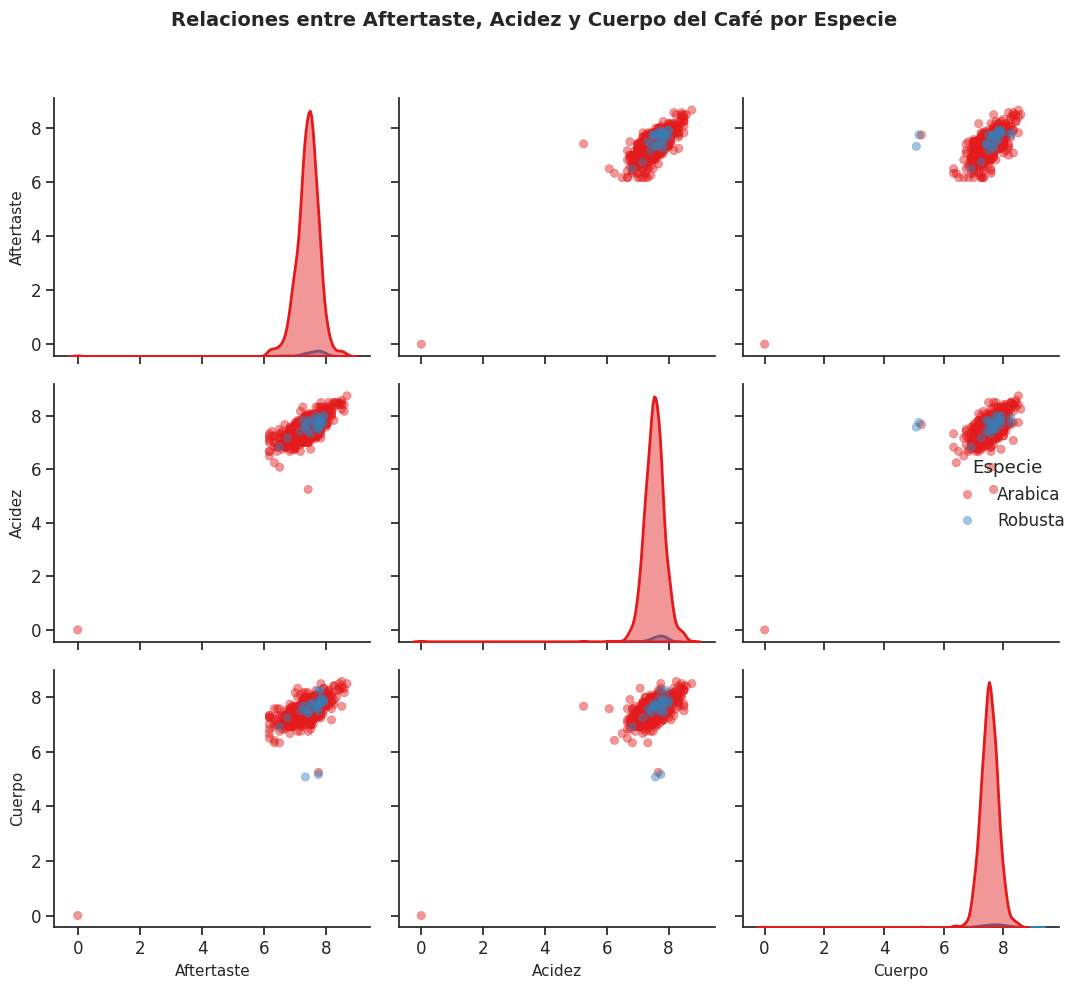

In [25]:
sns.set_theme(style="ticks", font_scale=1.1)

df10 = datos[["aftertaste", "acidity", "body", "species"]].dropna()

var_labels = {"aftertaste": "Aftertaste", "acidity": "Acidez", "body": "Cuerpo"}

g = sns.pairplot(
    df10,
    hue="species",
    vars=["aftertaste", "acidity", "body"],
    diag_kind="kde",
    plot_kws={"alpha": 0.45, "s": 35, "edgecolor": None},
    diag_kws={"fill": True, "alpha": 0.45, "linewidth": 2},
    palette="Set1",
    height=3.2,
    aspect=1,
)

for ax in g.axes.flatten():
    if ax is None:
        continue
    if ax.get_xlabel() in var_labels:
        ax.set_xlabel(var_labels[ax.get_xlabel()], fontsize=11)
    if ax.get_ylabel() in var_labels:
        ax.set_ylabel(var_labels[ax.get_ylabel()], fontsize=11)

g.figure.suptitle(
    "Relaciones entre Aftertaste, Acidez y Cuerpo del Café por Especie",
    y=1.03, fontsize=14, fontweight="bold",
)
g.legend.set_title("Especie")
plt.tight_layout()
plt.savefig("act10_pairplot_species.png", dpi=150, bbox_inches="tight")
plt.show()